In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
df = pd.read_csv("E:\\PM AI Program\\TASKS\\Salary Data.csv")
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


# Section 1: Data Understanding
1. Rows & Columns

In [38]:
df.shape

(375, 6)

2.Missing Value

In [39]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

3.Categorical & Numerical Columns

In [40]:
categorical_cols = df.select_dtypes(include='object').columns
numerical_cols = df.select_dtypes(exclude='object').columns

categorical_cols, numerical_cols

C:\Users\DELL\AppData\Local\Temp\ipykernel_820\717575190.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


(Index(['Gender', 'Education Level', 'Job Title'], dtype='str'),
 Index(['Age', 'Years of Experience', 'Salary'], dtype='str'))

4.Age Statistic

In [41]:
a= df['Age'].mean()
b= df['Age'].median()
c= df['Age'].std()

print(a)
print(b)
print(c)

37.43163538873995
36.0
7.069072938567494


5.Gender Proportion

In [42]:
df["Gender"].value_counts(normalize=True)*100

Gender
Male      52.010724
Female    47.989276
Name: proportion, dtype: float64

6.Education level Proportion

In [43]:
df["Education Level"].value_counts(normalize=True)*100

Education Level
Bachelor's    60.053619
Master's      26.273458
PhD           13.672922
Name: proportion, dtype: float64

# 🧹 Section 2: Data Cleaning
7.Rows with All NaN

In [44]:
df.isnull().all(axis=1).sum()
df.dropna(how='all',inplace=True)

8.Duplicate Row

In [45]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

9.Reset Index

In [46]:
df.reset_index(drop=True,inplace=True)

10.Encoding Categorical Variables

In [47]:
df_encoded =pd.get_dummies(df,drop_first=True)

#  Section 3: EDA

11. Age Distribution

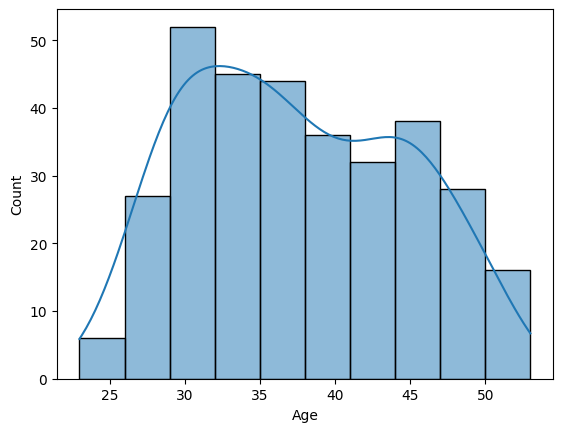

In [48]:
sns.histplot(df['Age'],kde=True)
plt.show()

12.Exprience Distribution

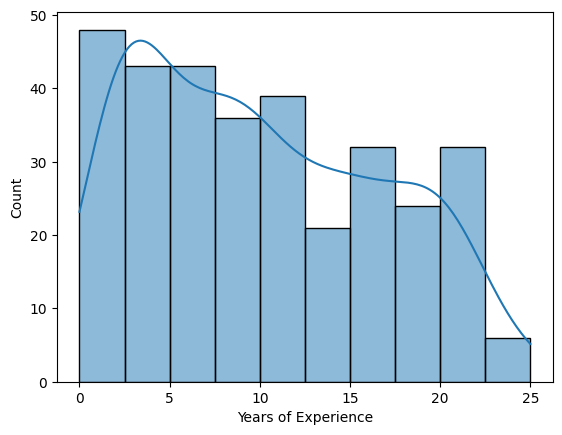

In [49]:
sns.histplot(df['Years of Experience'],kde=True)
plt.show()

13.Salary vs Education

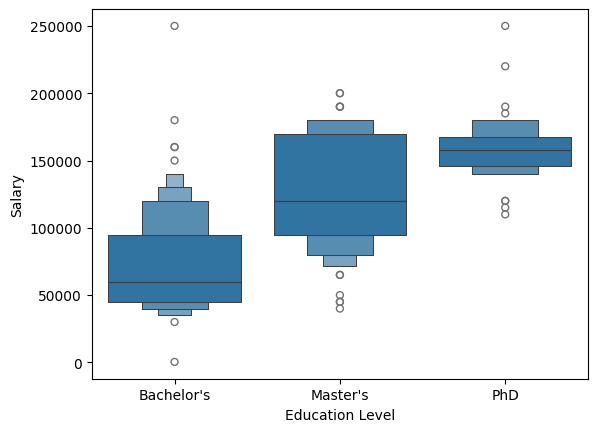

In [66]:
sns.boxenplot(x='Education Level', y='Salary',data=df)

plt.show()

14.Avg Salary by Gender

In [51]:
df.groupby('Gender')['Salary'].mean()

Gender
Female     96136.363636
Male      103472.647059
Name: Salary, dtype: float64

15. Education vs Salary

In [52]:
df.groupby('Education Level')['Salary'].mean()

Education Level
Bachelor's     73902.356021
Master's      127912.087912
PhD           158095.238095
Name: Salary, dtype: float64

16. Experience Categories

In [53]:
bins = [0,5,10,15,20,100]
labels = ['0-5','6-10','11-15','16-20','20+']

df['Exp Category'] = pd.cut(df['Years of Experience'], bins=bins, labels=labels)

df.groupby('Exp Category')['Salary'].mean()

Exp Category
0-5       49330.288462
6-10      92215.189873
11-15    115178.571429
16-20    158684.210526
20+      175400.000000
Name: Salary, dtype: float64

# Section 4: Correlation
17. Heatmap

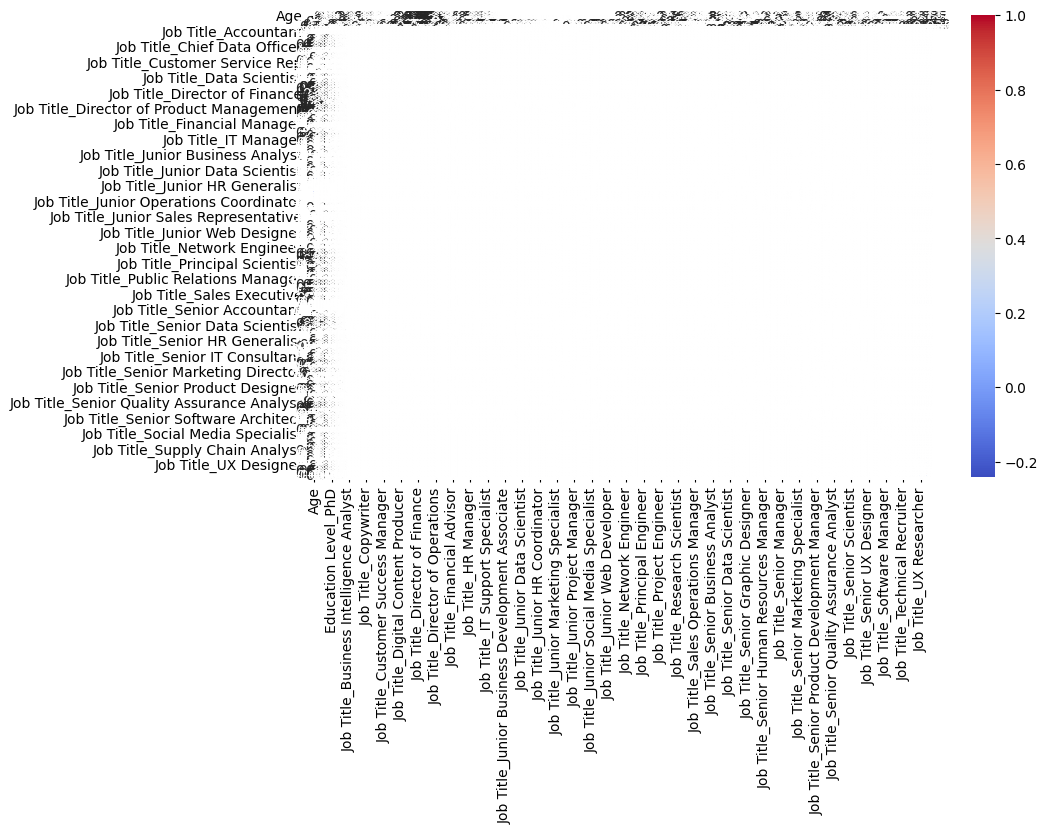

In [54]:
plt.figure(figsize=(10,6))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.show()

18.Scatter Matrix

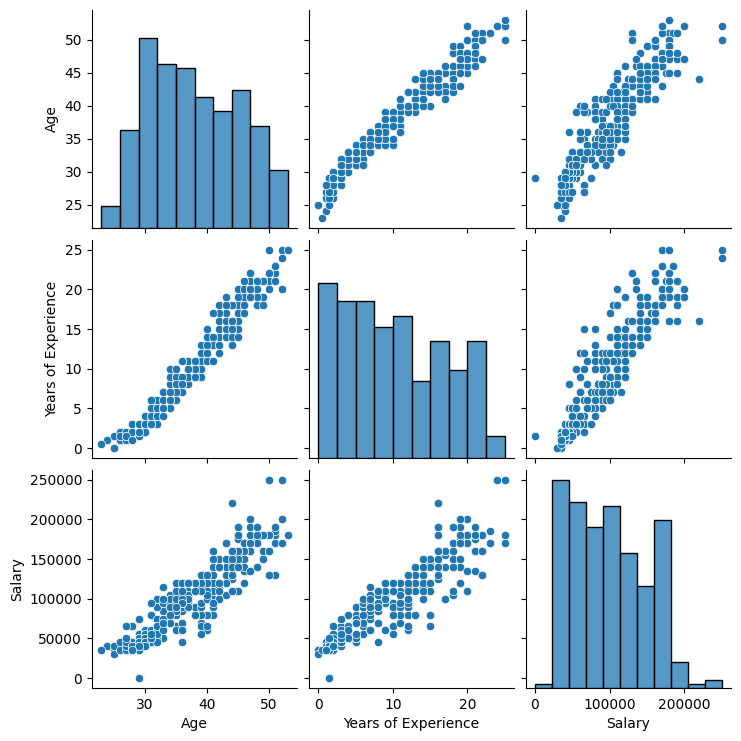

In [55]:
sns.pairplot(df)
plt.show()

# Section 5: Model Building
19. Features & Target

In [56]:
X = df_encoded.drop('Salary', axis=1)
y = df_encoded['Salary']

20. Train-Test Split

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

21. Algorithm Used

In [58]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


22.Training Score

In [59]:
model.score(X_train,y_train)

0.9865584938289437

# Section 6: Evaluation
23. R² Score

In [60]:
y_pred = model.predict(X_test)

from sklearn.metrics import r2_score

r2_score(y_test, y_pred)

0.8670436880629651

24. RMSE

In [61]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmse

np.float64(15851.154768860915)

25.Predicted vs Actual Plot

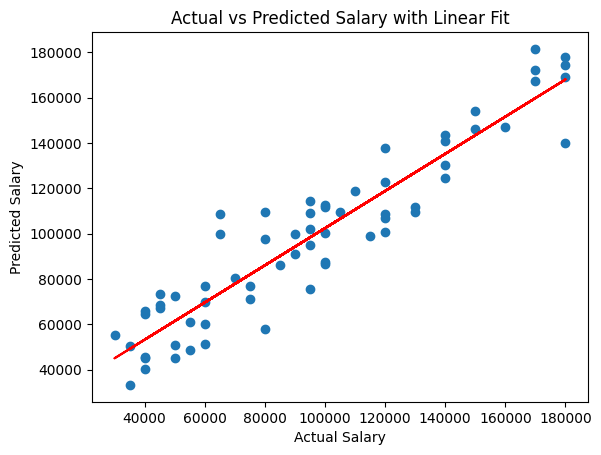

In [62]:

from turtle import color


plt.scatter(y_test, y_pred)

m, b = np.polyfit(y_test, y_pred,1 )
plt.plot(y_test, m*y_test + b,color='red')

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary with Linear Fit")

plt.show()

# Section 7: Critical Thinking (Short Answers)
26. Important Features
Years of Experience ✅
Education Level ✅
Age (moderate impact)
27. Important Preprocessing
Removing duplicates
Handling missing values
Encoding categorical variables
28. Improve Model
Feature engineering (e.g., experience²)
Try models:
Random Forest
XGBoost
Hyperparameter tuning
Normalize data